# Transfer Learning with MobileNetV2 on CIFAR-10
instead of training from scratch, using pretrained imagenet weights
two phases: feature extraction (frozen base) then fine-tuning (unfreeze top layers)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print(tf.__version__)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

2.21.0


train: (10000, 32, 32, 3), test: (2000, 32, 32, 3)


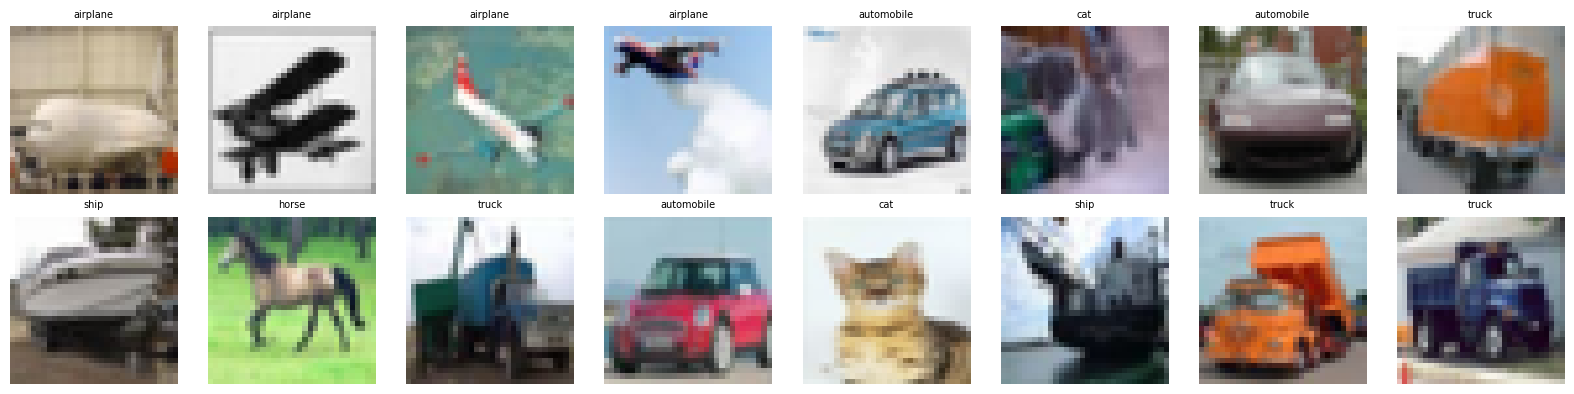

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
y_train = y_train.flatten()
y_test = y_test.flatten()

# using subset to keep training fast
# remove this if you want full dataset (takes longer)
idx_tr = np.random.choice(len(X_train), 10000, replace=False)
idx_te = np.random.choice(len(X_test), 2000, replace=False)
X_train, y_train = X_train[idx_tr], y_train[idx_tr]
X_test, y_test = X_test[idx_te], y_test[idx_te]

print(f"train: {X_train.shape}, test: {X_test.shape}")

# show some examples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i]], fontsize=7)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# MobileNetV2 needs at least 32x32, we'll upscale to 96x96
IMG_SIZE = 96

def preprocess(imgs):
    imgs = tf.image.resize(imgs.astype('float32'), (IMG_SIZE, IMG_SIZE))
    return keras.applications.mobilenet_v2.preprocess_input(imgs)

X_train_p = preprocess(X_train)
X_test_p = preprocess(X_test)
print(f"preprocessed: {X_train_p.shape}")

preprocessed: (10000, 96, 96, 3)


In [4]:
# load pretrained mobilenetv2, no top classifier
base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                   include_top=False, weights='imagenet')
base.trainable = False  # freeze for now

# add our own classifier on top
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = keras.Model(inputs, outputs)
model.compile(optimizer=keras.optimizers.Adam(0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print(f"trainable params: {sum(p.numpy().size for p in model.trainable_variables):,}")

trainable params: 362,122


In [5]:
# phase 1: feature extraction - base is frozen, only train the head
print("Phase 1: training head only...")

h1 = model.fit(X_train_p, y_train,
               batch_size=64, epochs=10,
               validation_split=0.1,
               callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
               verbose=1)

acc1 = model.evaluate(X_test_p, y_test, verbose=0)[1]
print(f"\nphase 1 test accuracy: {acc1:.4f}")

Phase 1: training head only...
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 103s 669ms/step - accuracy: 0.6489 - loss: 1.0643 - val_accuracy: 0.7920 - val_loss: 0.5947
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 117s 492ms/step - accuracy: 0.7908 - loss: 0.6319 - val_accuracy: 0.8200 - val_loss: 0.5287
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 79s 558ms/step - accuracy: 0.8273 - loss: 0.5176 - val_accuracy: 0.8310 - val_loss: 0.5149
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 86s 609ms/step - accuracy: 0.8462 - loss: 0.4484 - val_accuracy: 0.8400 - val_loss: 0.5259
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 71s 502ms/step - accuracy: 0.8639 - loss: 0.3966 - val_accuracy: 0.8290 - val_loss: 0.5260
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 78s 553ms/step - accuracy: 0.8777 - loss: 0.3571 - val_accuracy: 0.8270 - val_loss: 0.5372

phase 1 test accuracy: 0.8385


In [6]:
# phase 2: fine-tuning - unfreeze last 30 layers and train with very low lr
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=keras.optimizers.Adam(1e-5),  # much lower lr for fine-tuning
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Phase 2: fine-tuning last 30 layers...")
h2 = model.fit(X_train_p, y_train,
               batch_size=32, epochs=5,
               validation_split=0.1,
               callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
               verbose=1)

acc2 = model.evaluate(X_test_p, y_test, verbose=0)[1]
print(f"\nphase 2 test accuracy: {acc2:.4f}")
print(f"improvement from fine-tuning: {(acc2-acc1)*100:.2f}%")

Phase 2: fine-tuning last 30 layers...
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 137s 405ms/step - accuracy: 0.7549 - loss: 0.7453 - val_accuracy: 0.8170 - val_loss: 0.5755
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 143s 407ms/step - accuracy: 0.8064 - loss: 0.5748 - val_accuracy: 0.8310 - val_loss: 0.5385
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 118s 419ms/step - accuracy: 0.8328 - loss: 0.5138 - val_accuracy: 0.8440 - val_loss: 0.4992
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 136s 397ms/step - accuracy: 0.8462 - loss: 0.4549 - val_accuracy: 0.8530 - val_loss: 0.4701
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 108s 384ms/step - accuracy: 0.8550 - loss: 0.4412 - val_accuracy: 0.8590 - val_loss: 0.4437

phase 2 test accuracy: 0.8680
improvement from fine-tuning: 2.95%


              precision    recall  f1-score   support

    airplane       0.87      0.86      0.86       190
  automobile       0.94      0.93      0.94       203
        bird       0.88      0.82      0.85       201
         cat       0.84      0.71      0.77       199
        deer       0.74      0.86      0.80       192
         dog       0.81      0.81      0.81       179
        frog       0.86      0.93      0.89       222
       horse       0.90      0.89      0.89       211
        ship       0.90      0.96      0.93       205
       truck       0.93      0.90      0.92       198

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



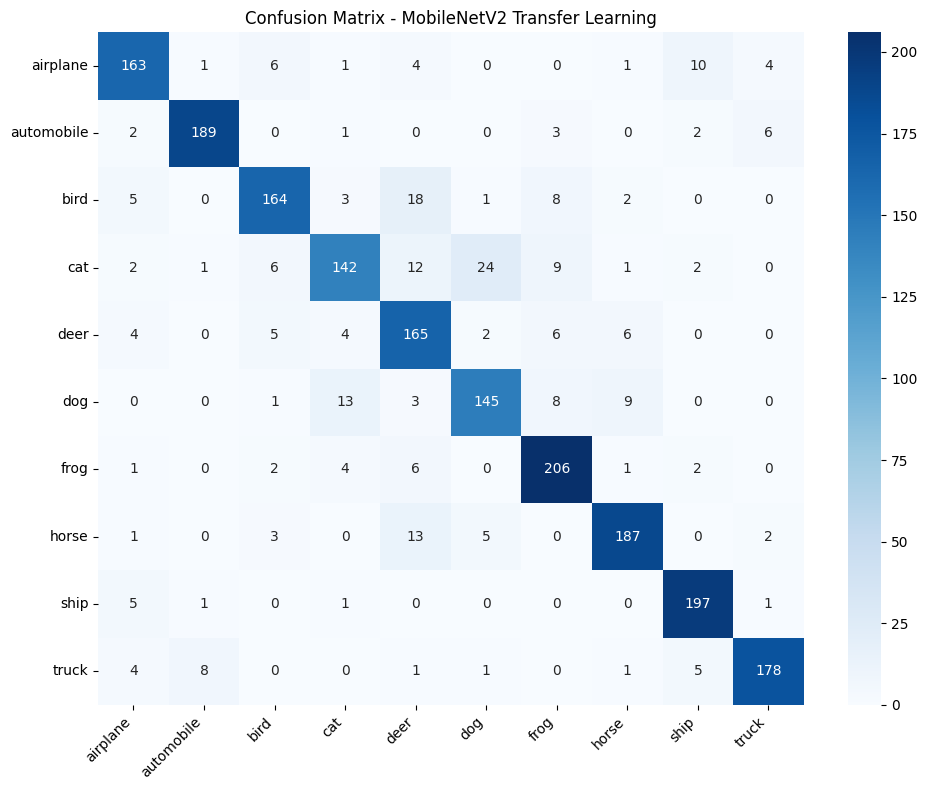

In [7]:
y_pred = np.argmax(model.predict(X_test_p, verbose=0), axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - MobileNetV2 Transfer Learning')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()